/home/wojtek/PycharmProjects/my_first_ds_project/.venv/lib/python3.12/site-packages/numpy/lib/_format_impl.py:838: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  array = pickle.load(fp, **pickle_kwargs)


Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 94ms/step - accuracy: 0.7681 - loss: 0.4718 - val_accuracy: 0.8484 - val_loss: 0.3590
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 28s 89ms/step - accuracy: 0.8896 - loss: 0.2781 - val_accuracy: 0.8520 - val_loss: 0.3400
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 29s 94ms/step - accuracy: 0.9171 - loss: 0.2214 - val_accuracy: 0.8480 - val_loss: 0.3454
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 31s 99ms/step - accuracy: 0.9377 - loss: 0.1692 - val_accuracy: 0.8444 - val_loss: 0.3711
Epoch 5/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 32s 101ms/step - accuracy: 0.9534 - loss: 0.1304 - val_accuracy: 0.8480 - val_loss: 0.4297
Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 15s 44ms/step - accuracy: 0.6001 - loss: 0.6543 - val_accuracy: 0.5488 - val_loss: 0.7315
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - accuracy: 0.8112 - loss: 0.4178 - val_accuracy: 0.8108 - val_loss: 0.4320
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 12s 40ms/step - accuracy: 0.9226 - loss: 0.2067 - val_acc

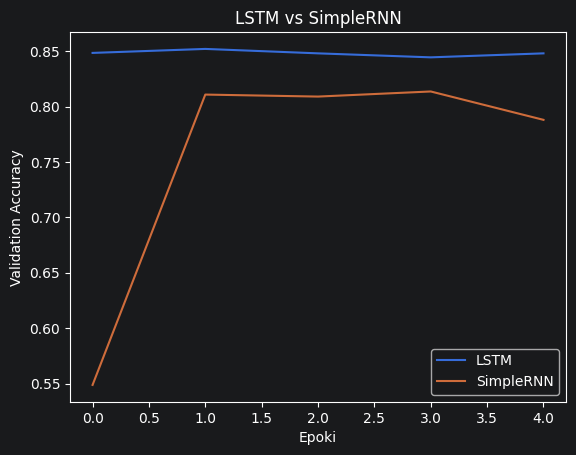

In [2]:
# Zadanie 3 - LSTM na IMDB
"""
Zbuduj model z Embedding + LSTM(64) + Dense na IMDB. Porownaj accuracy z SimpleRNN.

Dataset: keras.datasets.imdb

Wymagania:
LSTM z dropout=0.2
Porownanie z SimpleRNN (z zadania 2)
Krzywe uczenia
"""
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# =========================
# Dane
# =========================
max_features = 10000
maxlen = 200

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=max_features)

x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

# =========================
# Model LSTM
# =========================
lstm_model = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.LSTM(64, dropout=0.2),
    layers.Dense(1, activation="sigmoid")
])

lstm_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =========================
# Model SimpleRNN
# =========================
rnn_model = keras.Sequential([
    layers.Embedding(max_features, 128),
    layers.SimpleRNN(64),
    layers.Dense(1, activation="sigmoid")
])

rnn_model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# =========================
# Trening
# =========================
history_lstm = lstm_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

history_rnn = rnn_model.fit(
    x_train, y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

# =========================
# Wykres
# =========================
plt.plot(history_lstm.history["val_accuracy"], label="LSTM")
plt.plot(history_rnn.history["val_accuracy"], label="SimpleRNN")
plt.xlabel("Epoki")
plt.ylabel("Validation Accuracy")
plt.title("LSTM vs SimpleRNN")
plt.legend()
plt.show()

In [ ]:
# Zadanie 5
"""
Zbadaj wplyw maxlen na accuracy: wytrenuj ten sam model LSTM z maxlen = 50, 100, 200, 500. Jak dlugosc wplywa na wyniki i czas?

Dataset: keras.datasets.imdb

Wymagania:
4 eksperymenty z roznym maxlen
Tabela: maxlen, accuracy, czas treningu
Interpretacja
"""

import time
import pandas as pd

maxlens = [50, 100, 200, 500]
results = []

for maxlen in maxlens:

    (x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=10000)

    x_train = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=maxlen)
    x_test = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=maxlen)

    model = keras.Sequential([
        layers.Embedding(10000, 128),
        layers.LSTM(64, dropout=0.2),
        layers.Dense(1, activation="sigmoid")
    ])

    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    start = time.time()

    model.fit(
        x_train, y_train,
        epochs=3,
        batch_size=64,
        verbose=0
    )

    end = time.time()

    acc = model.evaluate(x_test, y_test, verbose=0)[1]

    results.append({
        "maxlen": maxlen,
        "accuracy": acc,
        "time": end - start
    })

df = pd.DataFrame(results)
print(df)

In [ ]:
# Zadanie 10
"""
Wygeneruj syntetyczny szereg czasowy (sinusoida + trend + szum). Wytrenuj GRU do predykcji nastepnej wartosci. Zwizualizuj predykcje.

Wymagania:
create_sequences() z oknem 30 krokow
GRU(32) + Dense(1)
Wykres: rzeczywiste vs predykcje
MSE, MAE
"""

import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =========================
# Generacja danych
# =========================
t = np.arange(0, 500)

signal = (
    np.sin(0.02 * t) +
    0.005 * t +                # trend
    0.2 * np.random.randn(len(t))  # szum
)

# =========================
# Sekwencje
# =========================
def create_sequences(data, window=30):
    X, y = [], []
    for i in range(len(data) - window):
        X.append(data[i:i+window])
        y.append(data[i+window])
    return np.array(X), np.array(y)

X, y = create_sequences(signal, 30)

# reshape dla RNN
X = X[..., np.newaxis]

# podział
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# =========================
# Model GRU
# =========================
model = keras.Sequential([
    layers.GRU(32, input_shape=(30,1)),
    layers.Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

# =========================
# Trening
# =========================
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_split=0.2,
    verbose=0
)

# =========================
# Predykcje
# =========================
pred = model.predict(X_test)

# =========================
# Metryki
# =========================
mse = mean_squared_error(y_test, pred)
mae = mean_absolute_error(y_test, pred)

print("MSE:", mse)
print("MAE:", mae)

# =========================
# Wykres
# =========================
plt.figure(figsize=(12,5))
plt.plot(y_test, label="Rzeczywiste")
plt.plot(pred, label="Predykcje")
plt.legend()
plt.title("GRU - predykcja szeregu czasowego")
plt.xlabel("Krok czasowy")
plt.ylabel("Wartość")
plt.show()